<a href="https://colab.research.google.com/github/ArduinoPLUS/aicar/blob/main/CNNMultiKA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

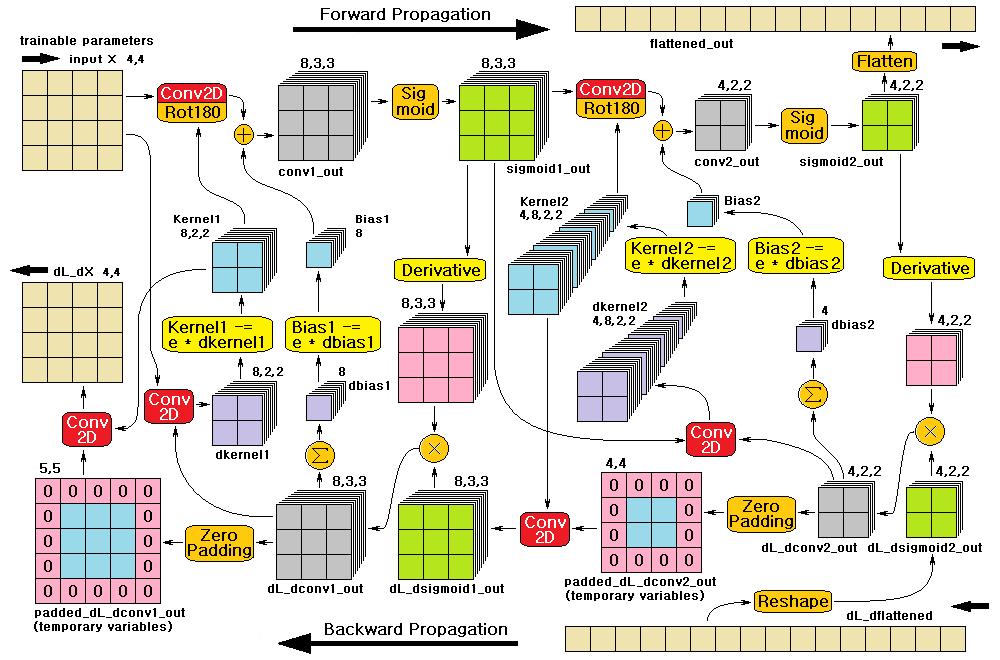

CNN class initialize ..........

self.kernel1:(8, 2, 2)
 [[[ 0.47298583 -0.68142588]
  [ 0.2424395  -1.70073563]]

 [[ 0.75314283 -1.53472134]
  [ 0.00512708 -0.12022767]]

 [[-0.80698188  2.87181939]
  [-0.59782292  0.47245699]]

 [[ 1.09595612 -1.2151688 ]
  [ 1.34235637 -0.12214979]]

 [[ 1.01251548 -0.91386915]
  [-1.02953021  1.20979645]]

 [[ 0.5018723   0.13884618]
  [ 0.64076111  0.52733267]]

 [[-1.15436024 -2.21333348]
  [-1.68175651 -1.78809425]]

 [[-2.21853495 -0.64743078]
  [-0.52840432 -0.03920917]]]

self.bias1:(8,)
 [ 0.21497595 -0.3843588  -0.25390408  0.07325207 -0.99720384 -0.71385629
  0.03541635 -0.67794537]

self.kernel2:(4, 8, 2, 2)
 [[[[-0.57188106 -0.10586232]
   [ 1.33583134  0.31866529]]

  [[-0.33759525 -0.58526828]
   [-0.11491994  2.24181779]]

  [[-3.14741652  0.53513589]
   [ 0.23249044  0.86761195]]

  [[-1.14821271  2.11434424]
   [ 1.00094276 -0.051415  ]]

  [[ 0.1597877  -0.71626359]
   [ 0.05052283 -0.14333741]]

  [[ 0.94357539  0.35764423]
   [-

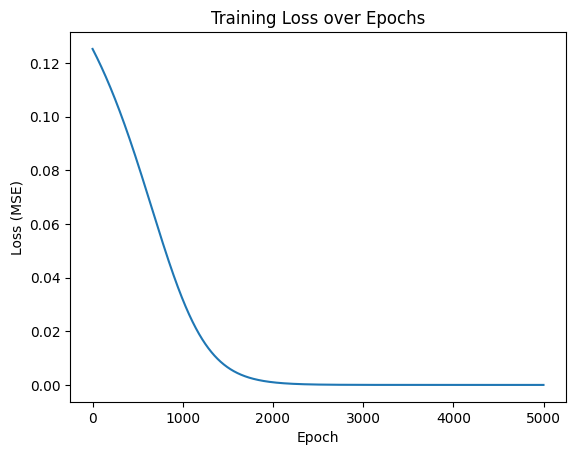

In [1]:
# Kernel Filter - Channels First Format (CHW)              <CNNmultiKA.ipynb>
#
#
#
#
#
import numpy as np
from scipy.signal import convolve2d
#
np.random.seed(12)                     # Set a random seed for reproducibility
#
def sigmoid(x):                        # Sigmoid 함수
  return 1 / (1 + np.exp(-x))
#
#-------------------------------------------------------------------------------
class DNN:
  def __init__(self, input_size, hidden_size1, hidden_size2, out_size):
    self.input_size = input_size
    self.hidden_size1 = hidden_size1
    self.hidden_size2 = hidden_size2
    self.out_size = out_size
#
    # 가중치 W, 바이어스 B 초기화
    self.W3 = np.random.randn(input_size, hidden_size1)
    self.B3 = np.random.randn(1, hidden_size1)
    self.W2 = np.random.randn(hidden_size1, hidden_size2)
    self.B2 = np.random.randn(1, hidden_size2)
    self.W1 = np.random.randn(hidden_size2, out_size)
    self.B1 = np.random.randn(1, out_size)
#
    # Store intermediate values for backward pass
    self.S3 = None
    self.Y3 = None
    self.S2 = None
    self.Y2 = None
    self.S1 = None
    self.Y1 = None
#
  def forward(self, X):               # 순전파 계산
    self.S3 = np.dot(X, self.W3) + self.B3
    self.Y3 = sigmoid(self.S3)
    self.S2 = np.dot(self.Y3, self.W2) + self.B2
    self.Y2 = sigmoid(self.S2)
    self.S1 = np.dot(self.Y2, self.W1) + self.B1
    self.Y1 = sigmoid(self.S1)
    return self.Y1
#
  def backward(self, X, D, learning_rate):       # 역전파 계산
    dL1 = (self.Y1 - D) * self.Y1 * (1 - self.Y1)
    dW1 = np.dot(self.Y2.T, dL1)
    dB1 = np.sum(dL1, axis=0, keepdims=True)
    dL2 = np.dot(dL1, self.W1.T) * self.Y2 * (1 - self.Y2)
    dW2 = np.dot(self.Y3.T, dL2)
    dB2 = np.sum(dL2, axis=0, keepdims=True)
    dL3 = np.dot(dL2, self.W2.T) * self.Y3 * (1 - self.Y3)
    dW3 = np.dot(X.T, dL3)
    dB3 = np.sum(dL3, axis=0, keepdims=True)
#
    # Calculate the gradient with respect to the input of the DNN (X)
    # dL/dX = dL/dS3 * dS3/dX = dL3 * W3.T
    dL_dX = np.dot(dL3, self.W3.T)
#
    # 가중치 및 편향 업데이트
    self.W1 -= learning_rate * dW1
    self.B1 -= learning_rate * dB1
    self.W2 -= learning_rate * dW2
    self.B2 -= learning_rate * dB2
    self.W3 -= learning_rate * dW3
    self.B3 -= learning_rate * dB3
#
    # Return the gradient with respect to the input of the DNN
    return dL_dX
#-------------------------------------------------------------------------------
class CNN:
  def __init__(self):
#
    print('CNN class initialize ..........')
#
    # First CNN layer: input 4x4, kernel 2x2, stride 1, filter 8
    self.kernel1 = np.random.randn(8, 2, 2)       # 8 Kernels of size 2x2
    self.bias1 = np.random.randn(8)               # 8 Biases
    print(f'\nself.kernel1:{self.kernel1.shape}\n',self.kernel1)
    print(f'\nself.bias1:{self.bias1.shape}\n',self.bias1)
#
    # Second CNN layer: input from first layer out (8x3x3),
    # kernel 2x2, stride 1, filter 4
    # 4 Kernels of size 2x2, applied to 8 input channels
    self.kernel2 = np.random.randn(4, 8, 2, 2)
    self.bias2 = np.random.randn(4)            # 4 Biases
    print(f'\nself.kernel2:{self.kernel2.shape}\n',self.kernel2)
    print(f'\nself.bias2:{self.bias2.shape}\n',self.bias2)
#
    # Store intermediate values for backward pass (Channels, Height, Width)
    self.conv1_out = None           # 컨볼류션1 출력(Output shape: 8x3x3)
    self.sigmoid1_out = None        # 활성화 함수1 출력
    self.conv2_out = None           # 컨볼류션2 출력(Output shape: 4x2x2)
    self.sigmoid2_out = None        # 활성화 함수2 출력
#
  def forward(self, X, epoch):                             # CNN Forward
#
    if(epoch == 0): print('\nCNN Forward pass ..........')
    if(epoch == 0): print(f'\nX.shape:{X.shape}\n',X)
#
    # First CNN layer
    conv1_out_shape = (8, 3, 3)    # CHANNELS FIRST: (Channels, Height, Width)
    self.conv1_out = np.zeros(conv1_out_shape)    # 0 으로 초기화
    self.sigmoid1_out = np.zeros(conv1_out_shape) # 0 으로 초기화
#
    # Iterate through each filter in the first layer
    for i in range(self.kernel1.shape[0]): # 8 Loop
      self.conv1_out[i, :, :] =\
      convolve2d(X, np.rot90(self.kernel1[i], k=2), mode='valid') + self.bias1[i] # 교차상관
    if(epoch == 0): print(f'\nconv1_out {i}{self.conv1_out.shape}\n',\
                             self.conv1_out)
#
    self.sigmoid1_out = sigmoid(self.conv1_out)
    if(epoch == 0): print(f'\nsigmoid1_out{self.sigmoid1_out.shape}\n',\
                            self.sigmoid1_out)
#
# Second CNN layer
    conv2_out_shape = (4, 2, 2) # CHANNELS FIRST: (Channels, Height, Width)
    self.conv2_out = np.zeros(conv2_out_shape)
    self.sigmoid2_out = np.zeros(conv2_out_shape)
#
    # Iterate through each filter in the second layer
    for i in range(self.kernel2.shape[0]):           # 4 Loop
      temp_conv = np.zeros((2, 2))
      # Iterate through each input channel from the previous layer
      for j in range(self.kernel2.shape[1]):         # 8 Loop
        temp_conv += convolve2d(self.sigmoid1_out[j, :, :],\
        np.rot90(self.kernel2[i, j], k=2), mode='valid')                        # 교차 상관
#
      self.conv2_out[i, :, :] = temp_conv + self.bias2[i]
      if(epoch == 0): print(f'\nconv2_out {i}{self.conv2_out.shape}\n', self.conv2_out)
#
    self.sigmoid2_out = sigmoid(self.conv2_out)
    flattened_out = self.sigmoid2_out.flatten() # Flatten the out
#
    if(epoch == 0):
      print(f'\nsigmoid2_out:{self.sigmoid2_out.shape}\n', self.sigmoid2_out)
      print(f'\nflattened_out:{flattened_out.shape}\n', flattened_out)
#
    return flattened_out
#
  def backward(self, dL_dflattened, learning_rate, X, epoch):    # CNN Backward
#
    if epoch == 0: print('\nBackward pass ..........')
    if epoch == 0: print(f'\ndL_dflattened:{dL_dflattened.shape}\n',dL_dflattened)
#
    # Reshape the gradient from the flattened layer back to the shape of sigmoid2_out
    dL_dsigmoid2_out = dL_dflattened.reshape(self.sigmoid2_out.shape) # (4, 2, 2)
    if epoch == 0:
      print(f'\ndL_dsigmoid2_out:{dL_dsigmoid2_out.shape}\n',dL_dsigmoid2_out)
#
    # Backpropagate through the sigmoid activation of the second CNN layer
    dL_dconv2_out = dL_dsigmoid2_out * self.sigmoid2_out * (1 - self.sigmoid2_out)
    if epoch == 0: print(f'\ndL_dconv2_out:{dL_dconv2_out.shape}\n',dL_dconv2_out)
#
    # 4,8,2,2 Backpropagate through the second CNN layer
    dkernel2 = np.zeros(self.kernel2.shape)
    dbias2 = np.sum(dL_dconv2_out, axis=(1, 2)) # Sum over spatial dimensions
    if epoch == 0: print(f'\ndbias2:{dbias2.shape}\n',dbias2)
    dL_dsigmoid1_out = np.zeros(self.sigmoid1_out.shape)   # (8, 3, 3)
#
    # 4,8,2,2 Iterate through each filter in the second layer
    for i in range(self.kernel2.shape[0]): # 4 Loop
      padded_dL_dconv2_out = np.pad(dL_dconv2_out[i, :, :], pad_width=1,\
      mode='constant', constant_values=0) # 1 개의 임시 변수
#
      if epoch == 0: print(f'\npadded_dL_dconv2_out:{i}\n',padded_dL_dconv2_out)
#
      # 4,8,2,2 Iterate through each input channel from the previous layer
      for j in range(self.kernel2.shape[1]): # 8 Loop
        # i=4 j=8 (sigmoid1_out=8장) 따라서 dkernel2 = 4 x 8 = 32장
        dkernel2[i, j] = convolve2d(self.sigmoid1_out[j, :, :],\
                         np.rot90(dL_dconv2_out[i, :, :],k=2), mode='valid') # 교차 상관
        # j=8, dL_dsigmoid1_out 은 1장(i)씩 8개 kernel2 conv 하여 합산 후
        # 한장으로 만들고 8장(j)으로 저장
        dL_dsigmoid1_out[j, :, :] += \
          convolve2d(padded_dL_dconv2_out, self.kernel2[i, j], mode='valid') # Math. Conv
#
    # Backpropagate through the sigmoid activation of the first CNN layer
    dL_dconv1_out = dL_dsigmoid1_out * self.sigmoid1_out * (1 - self.sigmoid1_out)
    if epoch == 0: print(f'\ndL_dconv1_out:{dL_dconv1_out.shape}\n',dL_dconv1_out)
#
    # Backpropagate through the first CNN layer
    dkernel1 = np.zeros(self.kernel1.shape)
    dbias1 = np.sum(dL_dconv1_out, axis=(1, 2)) # sum over spatial dimensions
    dL_dX = np.zeros(X.shape) # Gradient with respect to the input of the CNN
#
    # 8,2,2 Iterate through each filter in the first layer
    for i in range(self.kernel1.shape[0]): # 8 Loop
      dkernel1[i]=convolve2d(X,np.rot90(dL_dconv1_out[i,:,:],k=2),mode='valid') # 교차 상관
#
      # Calculate the gradient with respect to the input of the CNN (X)
      # dL/dX = dL/dS1 * dS1/dX = dL_dconv1_out * kernel1.T
      # Need to pad dL_dconv1_out to match the input shape size after convolution
      padded_dL_dconv1_out = np.pad(dL_dconv1_out[i, :, :], pad_width=1,\
                                    mode='constant', constant_values=0) # zero padding
#
      dL_dX += convolve2d(padded_dL_dconv1_out, self.kernel1[i], mode='valid') # Math. Conv
#
    self.kernel2 -= learning_rate * dkernel2    # Update weights and biases
    self.bias2 -= learning_rate * dbias2
    self.kernel1 -= learning_rate * dkernel1
    self.bias1 -= learning_rate * dbias1
#
    if epoch == 0:
      print(f'\npadded_dL_dconv1_out:{padded_dL_dconv1_out.shape}\n',\
              padded_dL_dconv1_out)
      print(f'\ndkernel1:{dkernel1.shape}\n',dkernel1)
      print(f'\ndbias1:{dbias1.shape}\n',dbias1)
      print(f'\ndkernel2:{dkernel2.shape}\n',dkernel2)
      print(f'\ndbias2:{dbias2.shape}\n',dbias2)
      print(f'\nself.kernel1:{self.kernel1.shape}\n',self.kernel1)
      print(f'\nself.bias1:{self.bias1.shape}\n',self.bias1)
      print(f'\nself.kernel2:{self.kernel2.shape}\n',self.kernel2)
      print(f'\nself.bias2:{self.bias2.shape}\n',self.bias2)
      print(f'\ndL_dX:{dL_dX.shape}\n',dL_dX)
#
    # dL_dX 는 입력 X 가 trained parameter 일 때 의미가 있다.
    # Return the gradient with respect to the input of the CNN
    return dL_dX
#
#===============================================================================
# Define learning rate and number of epochs
learning_rate = 0.01
epochs = 5000
#
# Instantiate the CNN and NeuralNetwork classes
cnn_model = CNN()
# The out of the second CNN layer is 4x2x2 (channels first),
# which flattens to a size of 4*2*2 = 16.
# The NeuralNetwork class takes input_size, hidden_size1, hidden_size2, out_size.
# We will set hidden_size1=8, hidden_size2=4, and out_size=1.
dnn_input_size = 4 * 2 * 2                                   # 16
dnn_hidden_size1 = 8
dnn_hidden_size2 = 4
dnn_out_size = 1
dnn_model = DNN(input_size=dnn_input_size, hidden_size1=dnn_hidden_size1, \
                hidden_size2=dnn_hidden_size2, out_size=dnn_out_size)
#
# 학습 데이터(X)
test_input = np.array([[0.11, 0.12, 0.13, 0.14],
                       [0.21, 0.22, 0.23, 0.24],
                       [0.31, 0.32, 0.33, 0.34],
                       [0.41, 0.42, 0.43, 0.44]])
#
target_value =np.array([0.55])     # sigmoid 를 사용하므로 반드시 0~1 범위의 수
#
loss_history = []                  # List to store loss values for plotting
#
# Training loop
print("\nStarting training...\n")
for epoch in range(epochs):
  # Forward pass through CNN
  flattened_cnn_out = cnn_model.forward(test_input, epoch)
  if epoch == 0:
    print(f'\nMain A flattened_cnn_out:{flattened_cnn_out.shape}\n', flattened_cnn_out)
#
  # Reshape flattened CNN out for DNN
  flattened_cnn_out_reshaped = flattened_cnn_out.reshape(1, -1)
  if epoch == 0:
    print(f'\nMain B flattened_cnn_out_reshaped:\
      {flattened_cnn_out_reshaped.shape}\n',flattened_cnn_out_reshaped)
#
  # Forward pass through NeuralNetwork
  dnn_out = dnn_model.forward(flattened_cnn_out_reshaped)
  if epoch == 0: print(f'\nMain C dnn_out:{dnn_out.shape}\n',dnn_out)
#
  # Calculate error (Mean Squared Error)
  error = target_value - dnn_out
  loss = np.mean(error**2)
#
  # Store the loss
  loss_history.append(loss)
#
  # Backward pass through NeuralNetwork
  # The backward method now returns the gradient with respect to its input
  dL_dflattened_cnn_out = dnn_model.backward(flattened_cnn_out_reshaped,\
                                             target_value, learning_rate)
#
  if epoch == 0:
    print('loss\n',loss)
    print('dL_dflattened_cnn_out\n',dL_dflattened_cnn_out.shape)
  # Optionally print loss at intervals
  if (epoch + 1) % 100 == 0:
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")
  # Backward pass through CNN
  # Pass the gradient from the flattened layer back to the CNN
  cnn_model.backward(dL_dflattened_cnn_out.flatten(), learning_rate, \
                     test_input, epoch)
#
print("\nTraining finished.")
print("Final DNN out:", dnn_out)
print("Target value:", target_value)
# Mean Absolute Error as a measure of final error
print("Final Error:", np.mean(np.abs(error)))
#
import matplotlib.pyplot as plt
# Plot the loss history
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.show()
#